# Demos: Lecture 15

In [7]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from lecture15_helpers import *

## Demo 1: Order finding

<img src="fig/qpe_full.png" width="800px">

In [2]:
N = 15
a = 8

# N = 7
# a = 5

In [3]:
num_target_qubits = int(np.floor(np.log2(N))) + 1

wires = qml.registers({
    "estimation_wires": 6,
    "target_wires": num_target_qubits,
    "work_wires": num_target_qubits + 2
})

dev = qml.device('default.qubit', shots=1000)

In [14]:
@qml.qnode(dev)
def find_order(N, a):
    

    return qml.counts(wires=wires["estimation_wires"])

In [15]:
counts = find_order(N, a)
samples = np.array(list(counts.keys()))
frequencies = np.array(list(counts.values()))

<BarContainer object of 4 artists>

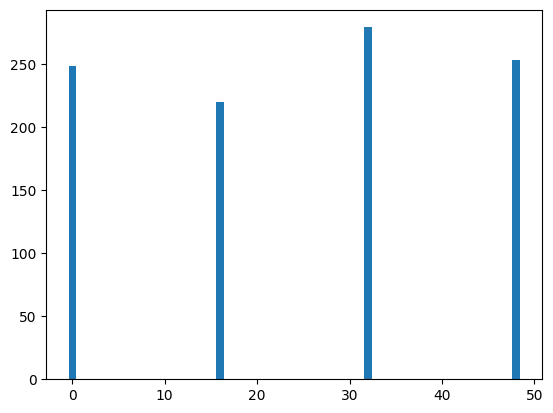

In [16]:
plt.bar([int(c, 2) for c in samples], frequencies)

In [17]:
possible_r = []
most_common = samples[np.argsort(frequencies)[::-1]]
sorted_frequencies = frequencies[np.argsort(frequencies)[::-1]]

for sample in most_common:
    phase = fractional_binary_to_float(sample)
    est_r = phase_to_order(phase, N)
    possible_r.append(est_r)

In [18]:
for r in range(0, N):
    print(f"r = {r}: {np.sum(sorted_frequencies[np.where(np.array(possible_r) == r)]) / dev.shots.total_shots}")

r = 0: 0.0
r = 1: 0.248
r = 2: 0.279
r = 3: 0.0
r = 4: 0.473
r = 5: 0.0
r = 6: 0.0
r = 7: 0.0
r = 8: 0.0
r = 9: 0.0
r = 10: 0.0
r = 11: 0.0
r = 12: 0.0
r = 13: 0.0
r = 14: 0.0


## Demo 2: Shor's algorithm

In [19]:
def run_order_finding(N, a):
    num_target_qubits = int(np.floor(np.log2(N))) + 1
    
    wires = qml.registers({
        "estimation_wires": 6,
        "target_wires": num_target_qubits,
        "work_wires": num_target_qubits + 2
    })
    
    dev = qml.device('default.qubit', shots=1)
    
    @qml.qnode(dev)
    def find_order():
        # Prepare the target register
        qml.PauliX(wires=wires["target_wires"][-1])
    
        # Prepare estimation register
        for wire in wires["estimation_wires"]:
            qml.Hadamard(wires=wire)
    
        for idx, est_wire in enumerate(wires["estimation_wires"][::-1]):
            for power in range(2 ** idx):
               qml.ctrl(qml.Multiplier, control=est_wire)(a, wires["target_wires"], N, wires["work_wires"])

        qml.adjoint(qml.QFT)(wires=wires["estimation_wires"])
        
        return qml.sample(wires=wires["estimation_wires"])
    
    sample = find_order()
    phase = fractional_binary_to_float(sample)
    est_r = phase_to_order(phase, N)
    
    return est_r

<img src="fig/shor-flowchart.jpeg" width="300px">

In [41]:
max_trials = 100

def shors_algorithm(N):
    num_actual_trials = 0
    
    for it in range(max_trials):
        a = int(np.random.choice(list(range(2, N - 1))))

        if not np.gcd(a, N) == 1:
            p = np.gcd(a, N)
            q = N // p
            print(f"\nChoice a = {a}: not coprime")
            continue

        print(f"\nChoice a = {a}: running quantum subroutine")
        
        num_actual_trials += 1
        
        r = run_order_finding(N, a)
        print(f"\tGuessed order r = {r}")
        
        if r % 2 == 1:
            print(f"\tOrder is odd")
            continue

        x = repeated_squaring(a, r // 2, N)
        
        if x == 1 or x == N - 1:
            print(f"Square root x = {x} is trivial")
            continue
        else:
            candidate_p = np.gcd(x - 1, N)
            candidate_q = np.gcd(x + 1, N)

            if candidate_p != 1 or candidate_q != 1:
                p = max(candidate_p, candidate_q)
                q = N // p
                print(f"\nFound solution after {num_actual_trials} shots:")
                print(f"r = {r}, x = {x}")
                print(f"p = {p}, q = {q}")
                return p, q

In [44]:
N = 15

p, q = shors_algorithm(N)


Choice a = 9: not coprime

Choice a = 7: running quantum subroutine
	Guessed order r = 1
	Order is odd

Choice a = 2: running quantum subroutine
	Guessed order r = 4

Found solution after 2 shots:
r = 4, x = 4
p = 5, q = 3
